In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_openml

# -------------------------------------------------------
# 1. 加载 MNIST（如果你已经有 X_small，换成你的变量即可）
# -------------------------------------------------------
print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data / 255.0
y = mnist.target.astype(int)

# 取小规模数据以加速训练
X_small = X[:5000]
y_small = y[:5000]
X_test = X[60000:]
y_test = y[60000:]

# 如果 X_small 是 DataFrame，先转成 numpy
X_small = X_small.to_numpy()
X_test = X_test.to_numpy()

Loading MNIST...


In [5]:

# -------------------------------------------------------
# 2. 用不同 PCA 比例降维 + KNN 测试分类效果
# -------------------------------------------------------

percentages = [0.2, 0.5, 0.8]

print("\n=== PCA + KNN Classification ===")
for p in percentages:
    print(f"\n➡️ 保留 {int(p*100)}% 信息:")

    pca = PCA(n_components=p)
    X_train_reduced = pca.fit_transform(X_small)
    X_test_reduced = pca.transform(X_test)

    # KNN 分类器
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_reduced, y_small)

    y_pred = knn.predict(X_test_reduced)
    acc = accuracy_score(y_test, y_pred)

    print(f"PCA {p*100:.0f}% → Accuracy = {acc:.4f}")


=== PCA + KNN Classification ===

➡️ 保留 20% 信息:
PCA 20% → Accuracy = 0.4609

➡️ 保留 50% 信息:
PCA 50% → Accuracy = 0.8910

➡️ 保留 80% 信息:
PCA 80% → Accuracy = 0.9438



Reconstructing images...


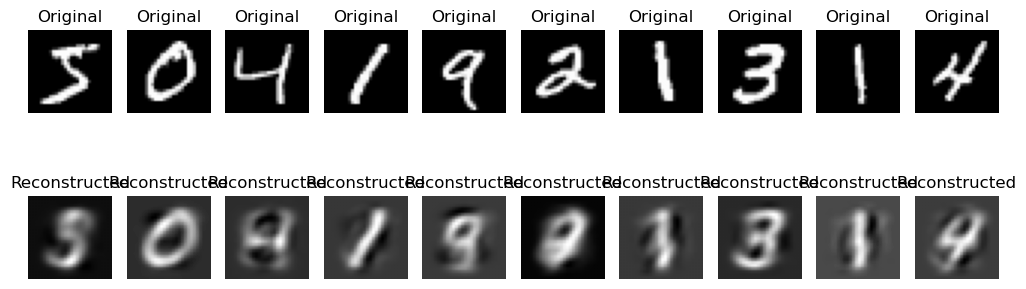

In [6]:
# -------------------------------------------------------
# 3. 图像重建测试 (inverse_transform)
# -------------------------------------------------------
print("\nReconstructing images...")

pca = PCA(n_components=0.5)   # 选择 50% 重建（你可以换成 0.2 或 0.8）
X_train_reduced = pca.fit_transform(X_small)
X_train_reconst = pca.inverse_transform(X_train_reduced)

# 画前 10 张图像
num_images = 10
plt.figure(figsize=(10, 4))

for i in range(num_images):
    # 原图
    plt.subplot(2, num_images, i + 1)
    plt.imshow(X_small[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # 重建图
    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(X_train_reconst[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()